# Model Building

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys; sys.path.insert(0, "..")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score

from src.data_preparation import load_and_prepare, get_feature_target_split
from src.model import (build_pipeline_rfc, build_pipeline_lgbm, build_pipeline_xgb,
                       churn_prediction, get_optimal_threshold,
                       BEST_PARAMS_RFC, BEST_PARAMS_LGBM, BEST_PARAMS_XGB)

%matplotlib inline
sns.set_style("darkgrid")

In [2]:
import sklearn
sklearn.set_config(transform_output="pandas")

## i. Random Forest

### 1. Load & Split Data

In [3]:
df, encoder = load_and_prepare(
    "../data/E Commerce Dataset.xlsx",
    is_excel=True,
    sheet_name="E Comm",
    fit_encoder=True,
)
X, y = get_feature_target_split(df)
feature_names = X.columns.tolist()

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)
print(f"Train: {x_train.shape} | Test: {x_test.shape}")
print(f"Churn rate — Train: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

Train: (4222, 17) | Test: (1408, 17)
Churn rate — Train: 0.168 | Test: 0.168


Stratified split preserves the ~17% churn ratio in both sets.

### 2. Pipeline

In [4]:
# The pipeline chains median imputation -> RandomForestClassifier for imputer to fit inside each CV fold
pipeline_rfc = build_pipeline_rfc()
print(pipeline_rfc)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight={0: 1, 1: 3.4},
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=20,
                                        min_samples_split=30,
                                        min_weight_fraction_leaf=0,
                                        n_estimators=1000, n_jobs=-1,
                                        random_state=42))])


In [5]:
# The pipeline chains median imputation -> LightGBMClassifier for imputer to fit inside each CV fold
pipeline_lgbm = build_pipeline_lgbm()
print(pipeline_lgbm)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 LGBMClassifier(class_weight={0: 1, 1: 2.9},
                                learning_rate=0.005, max_depth=4,
                                n_estimators=500, n_jobs=-1, num_leaves=10,
                                random_state=42, verbose=-1))])


In [6]:
# The pipeline chains median imputation -> XGBoostClassifier for imputer to fit inside each CV fold
pipeline_xgb = build_pipeline_xgb()
print(pipeline_xgb)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.3, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='auc',
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
              

### 3. Cross-Validation Baseline

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# AUC is more robust than F1 for imbalanced data in CV

In [8]:
# For Random Forest Classifier

cv_scores_rfc = cross_val_score(
    pipeline_rfc, x_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
)
print(f"CV AUC per fold: {cv_scores_rfc.round(4)}")
print(f"Mean: {cv_scores_rfc.mean():.4f}  Std: {cv_scores_rfc.std():.4f}")

CV AUC per fold: [0.8945 0.8747 0.8798 0.8626 0.8465]
Mean: 0.8716  Std: 0.0162


In [9]:
# For LightGBM Classifier

cv_scores_lgbm = cross_val_score(
    pipeline_lgbm, x_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
)
print(f"CV AUC per fold: {cv_scores_lgbm.round(4)}")
print(f"Mean: {cv_scores_lgbm.mean():.4f}  Std: {cv_scores_lgbm.std():.4f}")

CV AUC per fold: [0.898  0.8741 0.883  0.8632 0.8512]
Mean: 0.8739  Std: 0.0161


In [10]:
# For XGBoost Classifier

cv_scores_xgb = cross_val_score(
    pipeline_xgb, x_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
)
print(f"CV AUC per fold: {cv_scores_xgb.round(4)}")
print(f"Mean: {cv_scores_xgb.mean():.4f}  Std: {cv_scores_xgb.std():.4f}")

CV AUC per fold: [0.9059 0.8827 0.8879 0.8764 0.8613]
Mean: 0.8828  Std: 0.0146


### 4. Train and Evaluate

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 RandomForestClassifier(class_weight={0: 1, 1: 3.4},
                                        criterion='entropy', max_depth=5,
                                        min_samples_leaf=20,
                                        min_samples_split=30,
                                        min_weight_fraction_leaf=0,
                                        n_estimators=1000, n_jobs=-1,
                                        random_state=42))])

Test Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.90      0.91      1171
           1       0.55      0.62      0.58       237

    accuracy                           0.85      1408
   macro avg       0.73      0.76      0.74      1408
weighted avg       0.86      0.85      0.85      1408

Test Accuracy Score: 0.8494318181818182
--------------------------------------------------

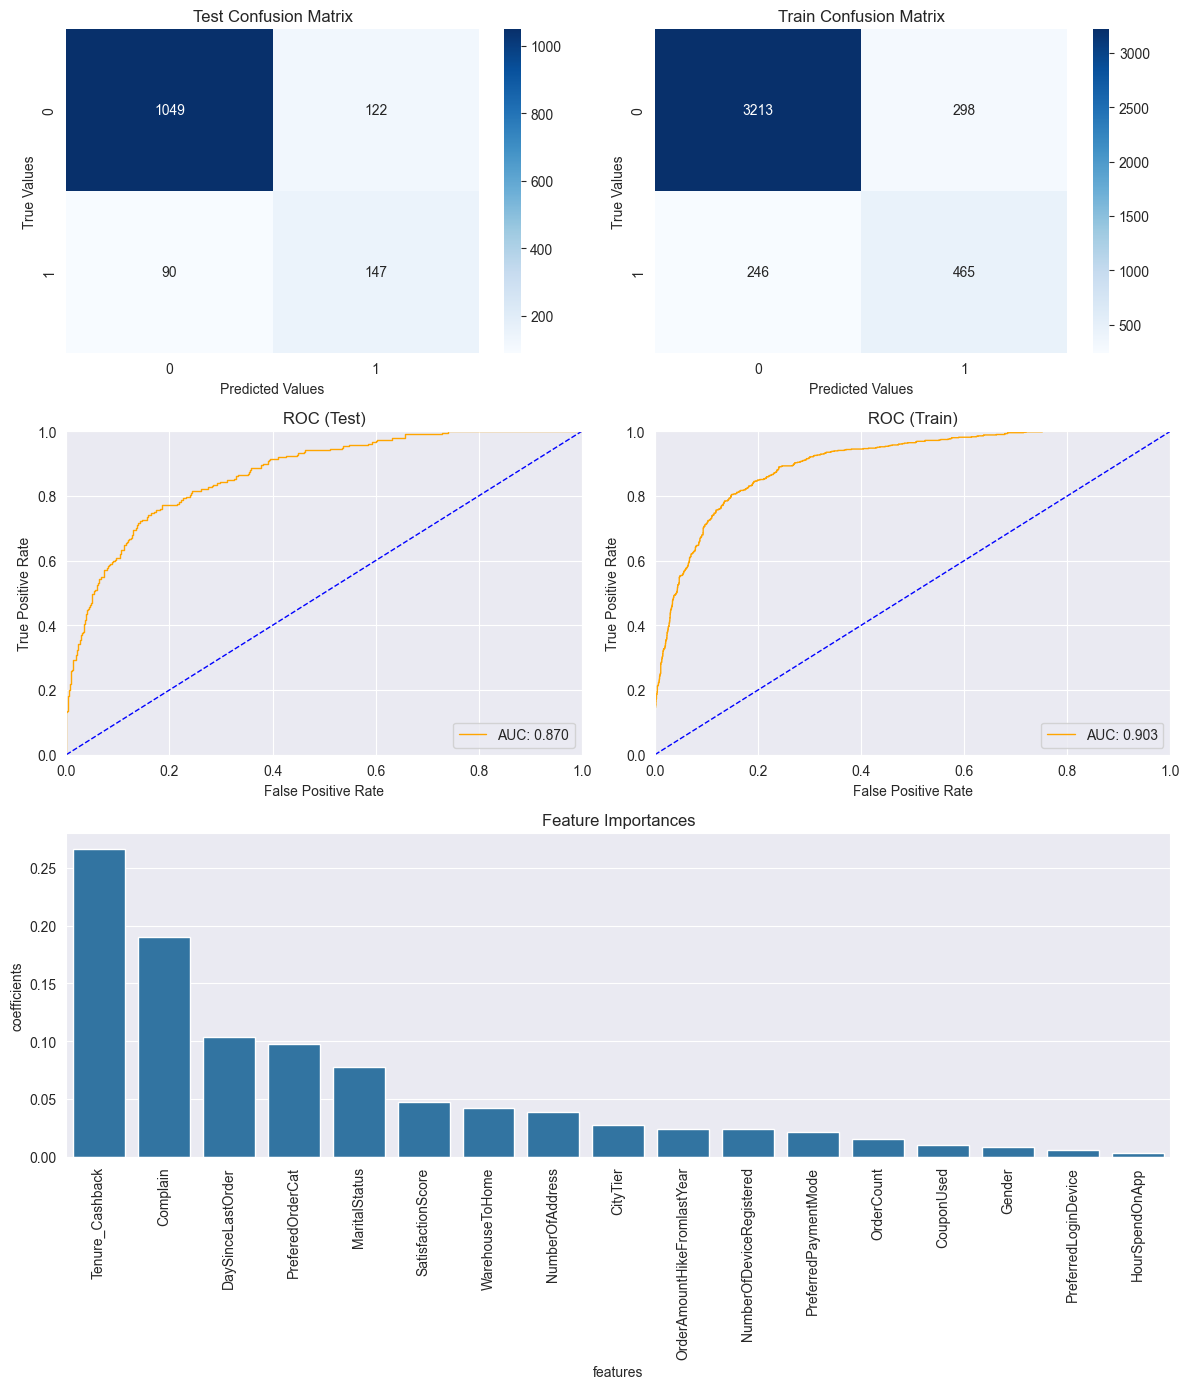

In [11]:
# Random Forest Classifier

churn_prediction(build_pipeline_rfc(), x_train, x_test, y_train, y_test, feature_names, cf="features")

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 LGBMClassifier(class_weight={0: 1, 1: 2.9},
                                learning_rate=0.005, max_depth=4,
                                n_estimators=500, n_jobs=-1, num_leaves=10,
                                random_state=42, verbose=-1))])

Test Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      1171
           1       0.60      0.61      0.61       237

    accuracy                           0.87      1408
   macro avg       0.76      0.76      0.76      1408
weighted avg       0.87      0.87      0.87      1408

Test Accuracy Score: 0.8657670454545454
--------------------------------------------------
Train Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.93      0.93      3511
           1       0.64      0.66      0.65       711

  

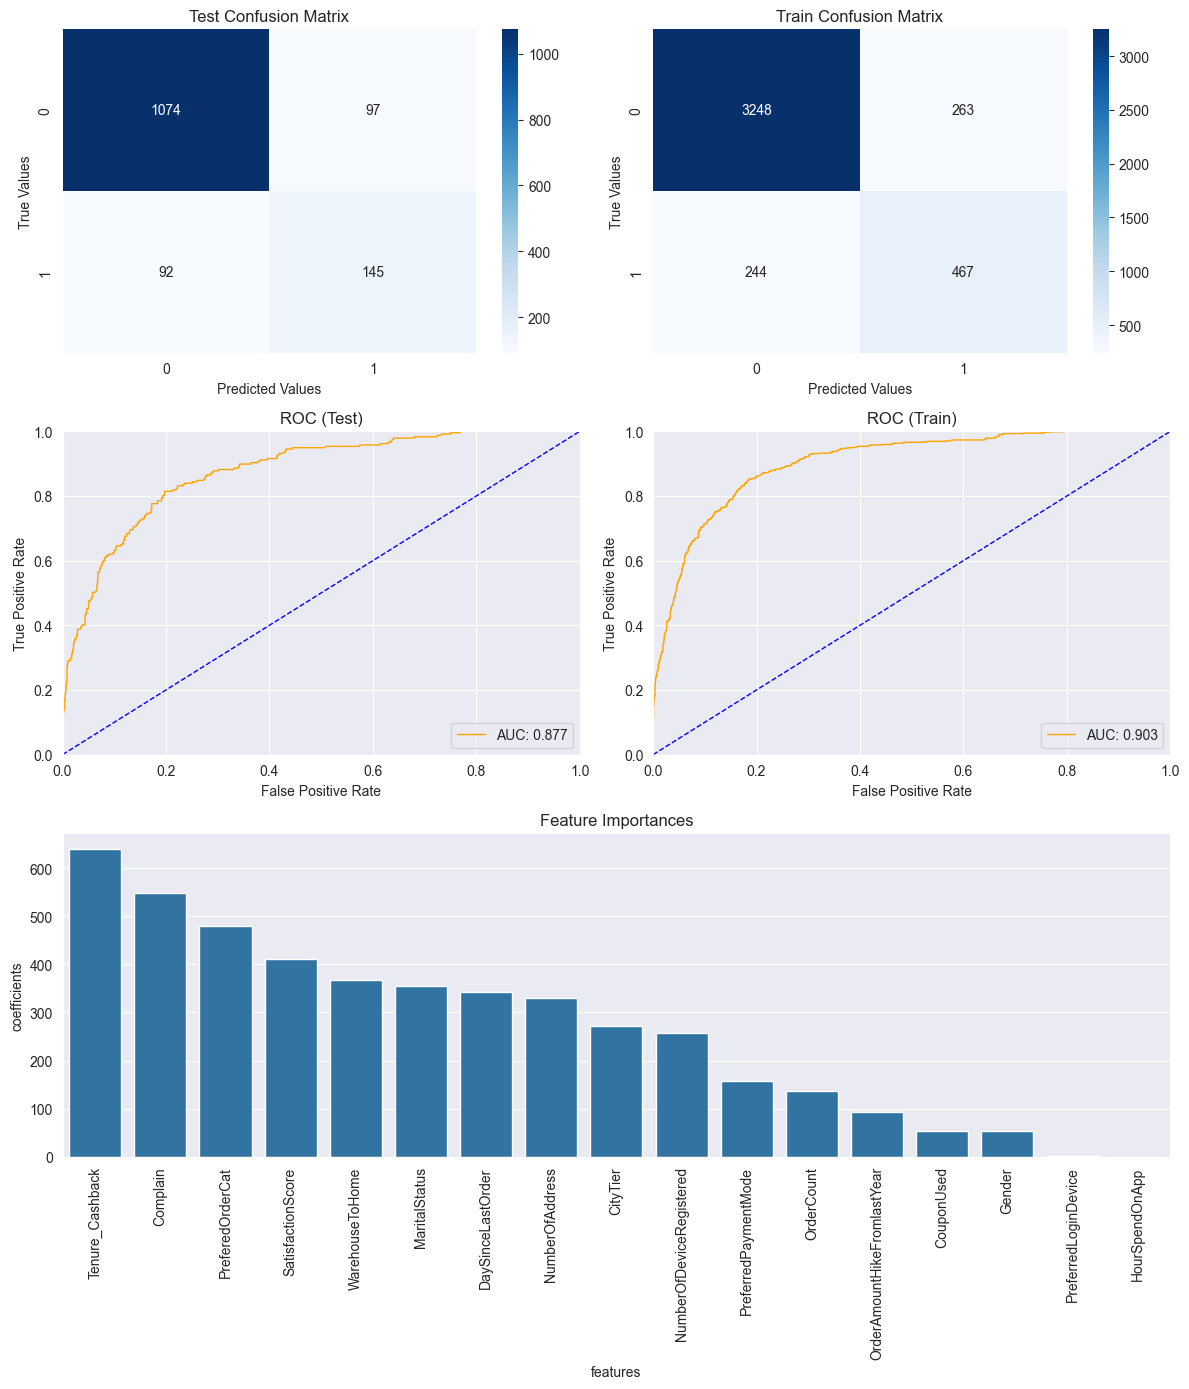

In [12]:
# LightGBM Classsifier

churn_prediction(
    build_pipeline_lgbm(), x_train, x_test, y_train, y_test, feature_names, cf="features"
)

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.3, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='auc',
                               feature_types=None, feature_weights=None,
                               gamma=0.1, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
              

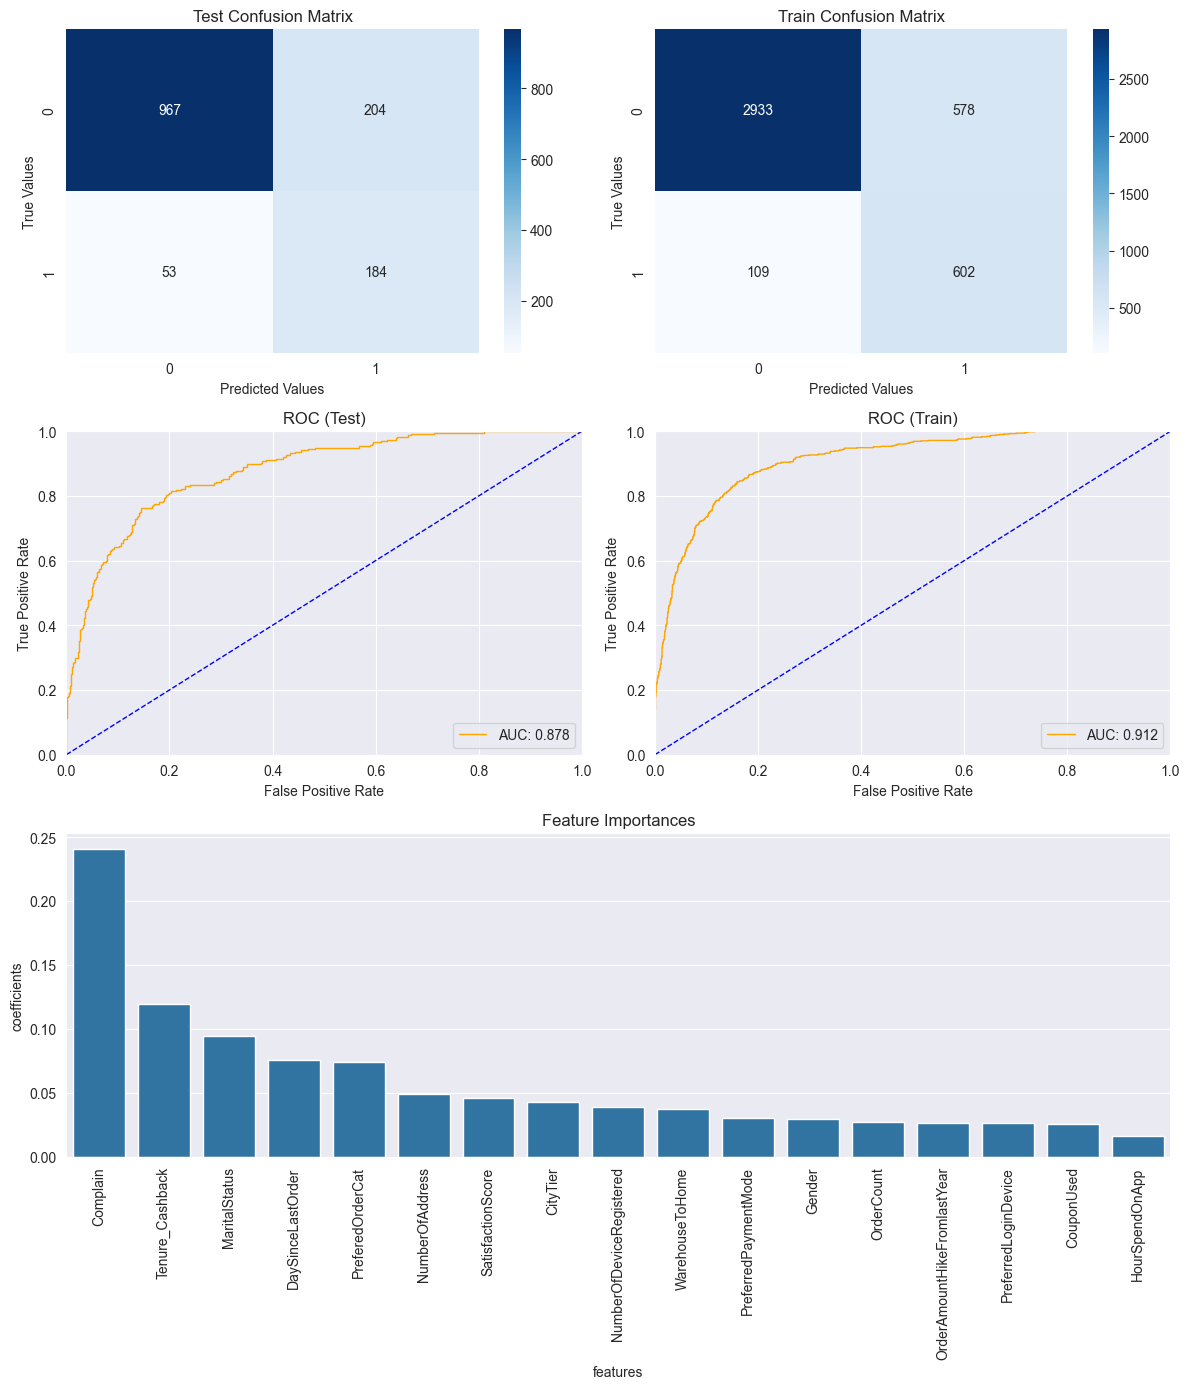

In [13]:
# XGBoost Classifier

churn_prediction(
    build_pipeline_xgb(), x_train, x_test, y_train, y_test, feature_names, cf="features"
)

### 5. Overfitting Diagnosis

A healthy model should have a **small gap** between training and test AUC (ideally < 0.03). A training AUC near 1.0 with any notable test drop indicates memorisation.

In [14]:
# Random Forest

final_rfc = build_pipeline_rfc()
final_rfc.fit(x_train, y_train)

train_auc = roc_auc_score(y_train, final_rfc.predict_proba(x_train)[:, 1])
test_auc = roc_auc_score(y_test, final_rfc.predict_proba(x_test)[:, 1])

print(f"Train AUC: {train_auc:.4f}")
print(f" Test AUC: {test_auc:.4f}")
print(f"      Gap: {train_auc - test_auc:.4f}  (target: < 0.030)")

Train AUC: 0.9032
 Test AUC: 0.8704
      Gap: 0.0328  (target: < 0.030)


In [15]:
# LightGBM

final_lgbm = build_pipeline_lgbm()
final_lgbm.fit(x_train, y_train)

train_auc = roc_auc_score(y_train, final_lgbm.predict_proba(x_train)[:, 1])
test_auc = roc_auc_score(y_test, final_lgbm.predict_proba(x_test)[:, 1])

print(f"Train AUC: {train_auc:.4f}")
print(f" Test AUC: {test_auc:.4f}")
print(f"      Gap: {train_auc - test_auc:.4f}  (target: < 0.030)")

Train AUC: 0.9035
 Test AUC: 0.8769
      Gap: 0.0266  (target: < 0.030)


In [16]:
# XGBoost

final_xgb = build_pipeline_xgb()
final_xgb.fit(x_train, y_train)

train_auc = roc_auc_score(y_train, final_xgb.predict_proba(x_train)[:, 1])
test_auc = roc_auc_score(y_test, final_xgb.predict_proba(x_test)[:, 1])

print(f"Train AUC: {train_auc:.4f}")
print(f" Test AUC: {test_auc:.4f}")
print(f"      Gap: {train_auc - test_auc:.4f}  (target: < 0.030)")

Train AUC: 0.9121
 Test AUC: 0.8785
      Gap: 0.0336  (target: < 0.030)


### 6. Threshold Optimisation
For finding threshold that maximizes f1 as default 0.5 threshold is not usually optimal for imbalanced data


In [17]:
# Random Forest

threshold = get_optimal_threshold(final_rfc, x_test, y_test)

probs = final_rfc.predict_proba(x_test)[:, 1]
preds = (probs >= threshold).astype(int)
print(classification_report(y_test, preds))

Optimal threshold: 0.4526  |  F1: 0.5965
              precision    recall  f1-score   support

           0       0.94      0.86      0.90      1171
           1       0.51      0.72      0.60       237

    accuracy                           0.84      1408
   macro avg       0.72      0.79      0.75      1408
weighted avg       0.87      0.84      0.85      1408



In [18]:
# LightGBM

threshold = get_optimal_threshold(final_lgbm, x_test, y_test)

probs = final_lgbm.predict_proba(x_test)[:, 1]
preds = (probs >= threshold).astype(int)
print(classification_report(y_test, preds))

Optimal threshold: 0.5006  |  F1: 0.6054
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      1171
           1       0.60      0.61      0.61       237

    accuracy                           0.87      1408
   macro avg       0.76      0.76      0.76      1408
weighted avg       0.87      0.87      0.87      1408



In [19]:
# XGBoost

threshold = get_optimal_threshold(final_xgb, x_test, y_test)

probs = final_xgb.predict_proba(x_test)[:, 1]
preds = (probs >= threshold).astype(int)
print(classification_report(y_test, preds))

Optimal threshold: 0.5378  |  F1: 0.6156
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      1171
           1       0.52      0.76      0.62       237

    accuracy                           0.84      1408
   macro avg       0.73      0.81      0.76      1408
weighted avg       0.87      0.84      0.85      1408



### 7. Conclusion and Save findings
XGBoost is performing the best among them. It is chosen for the final modeling.

Run `python scripts/train.py` to train and dump the model to `models/` for the API.